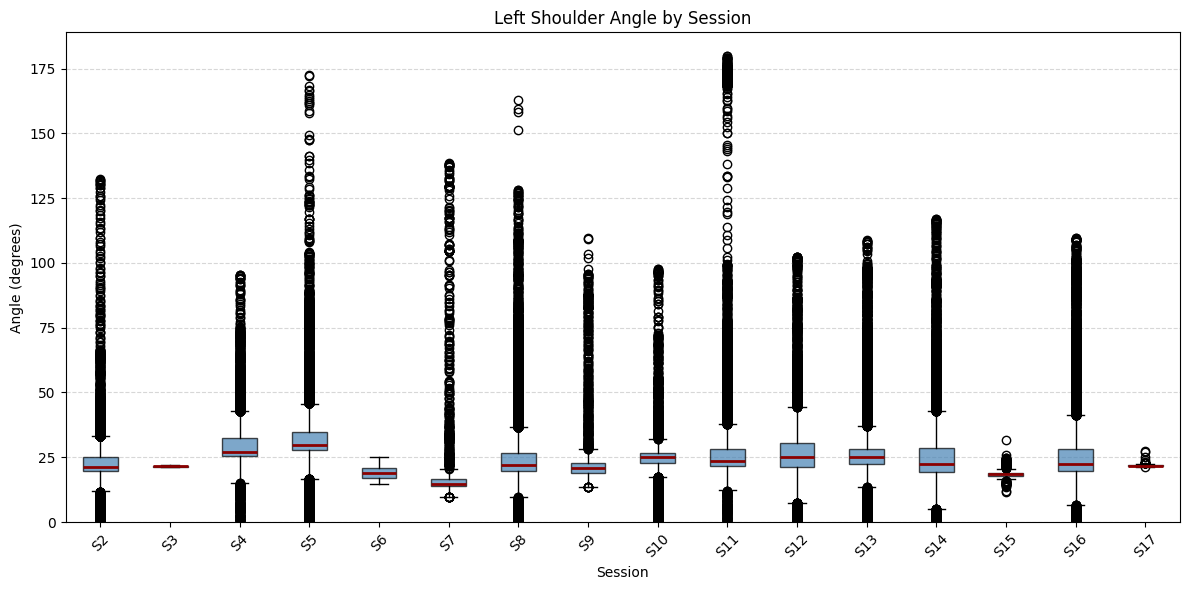

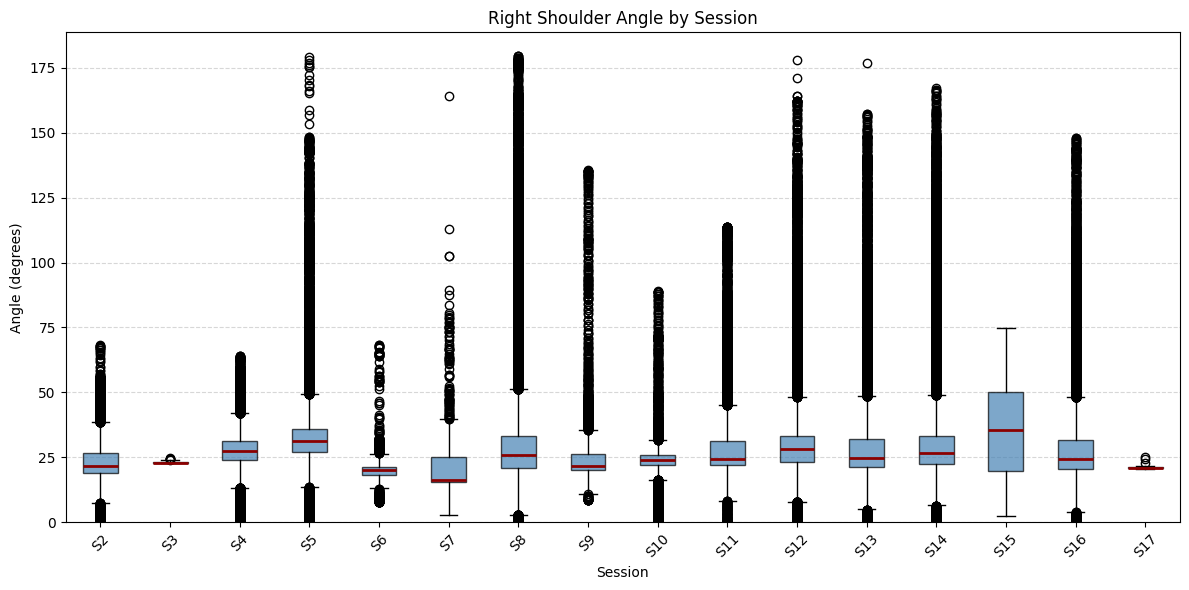

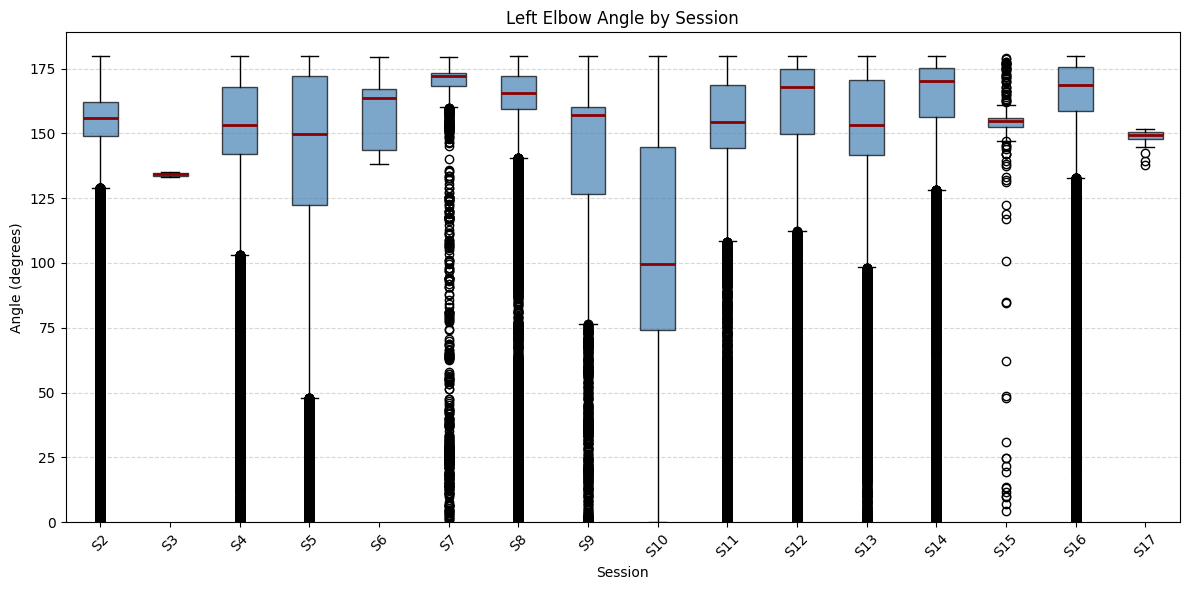

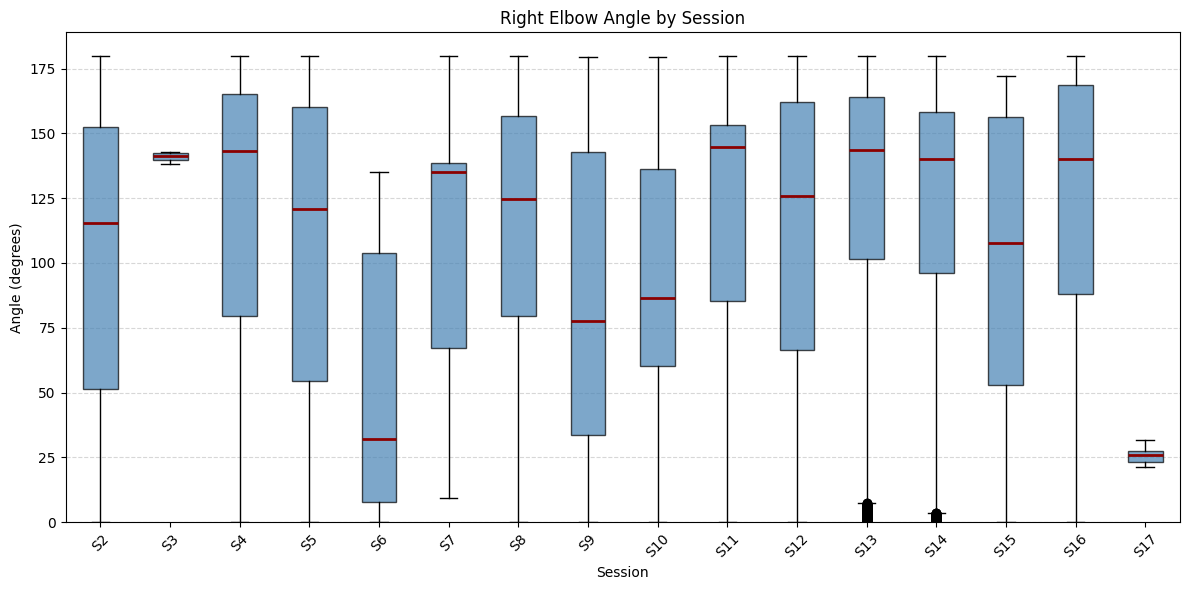

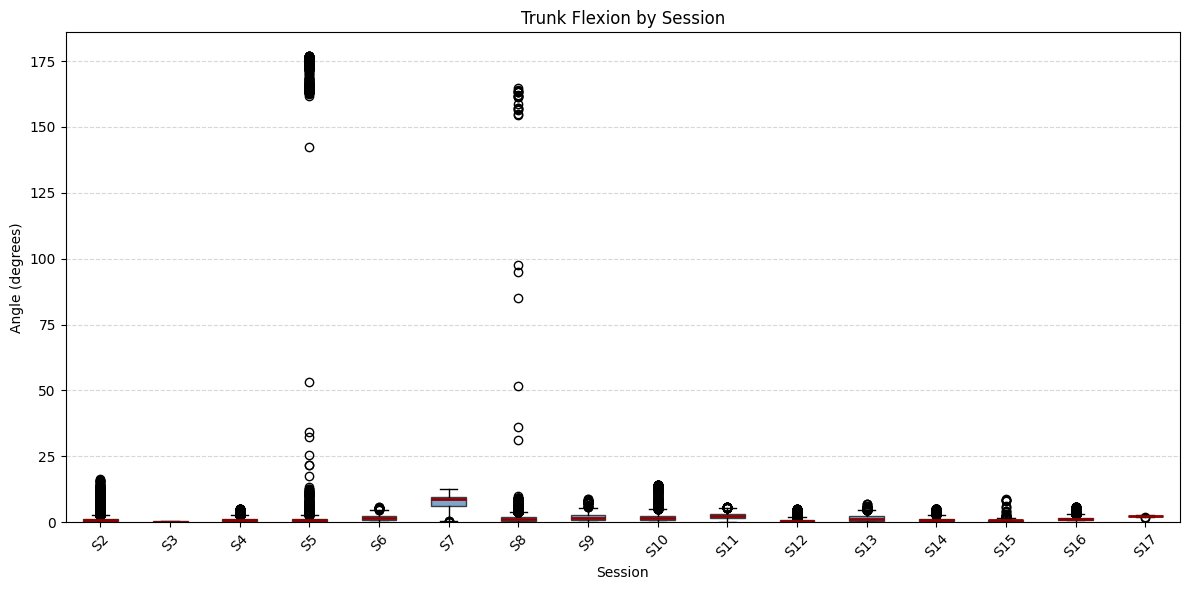

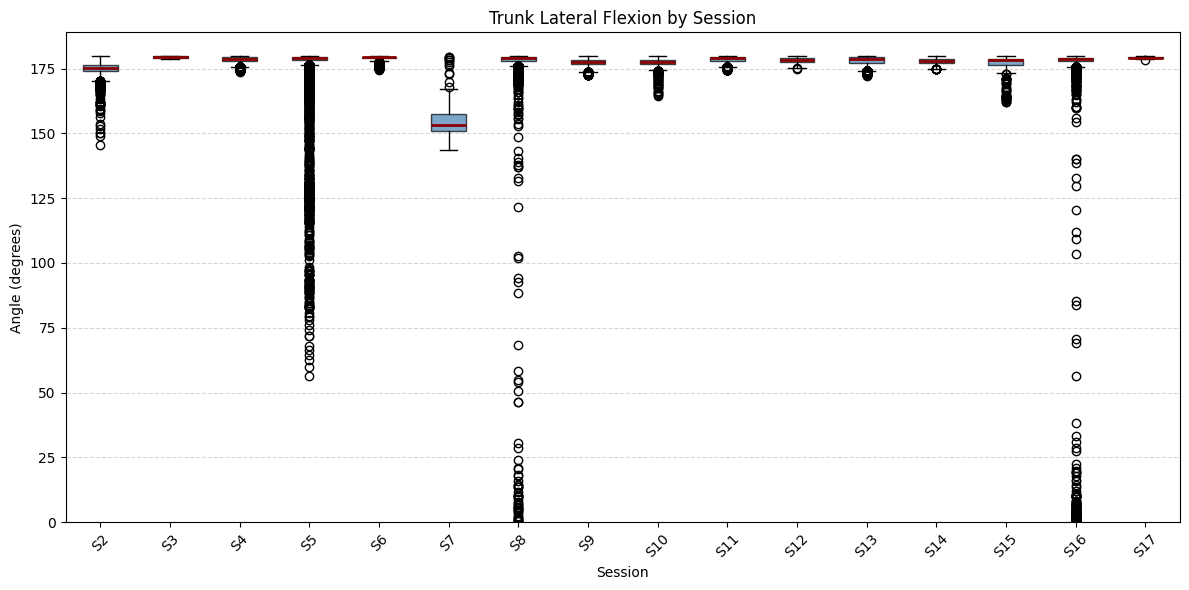

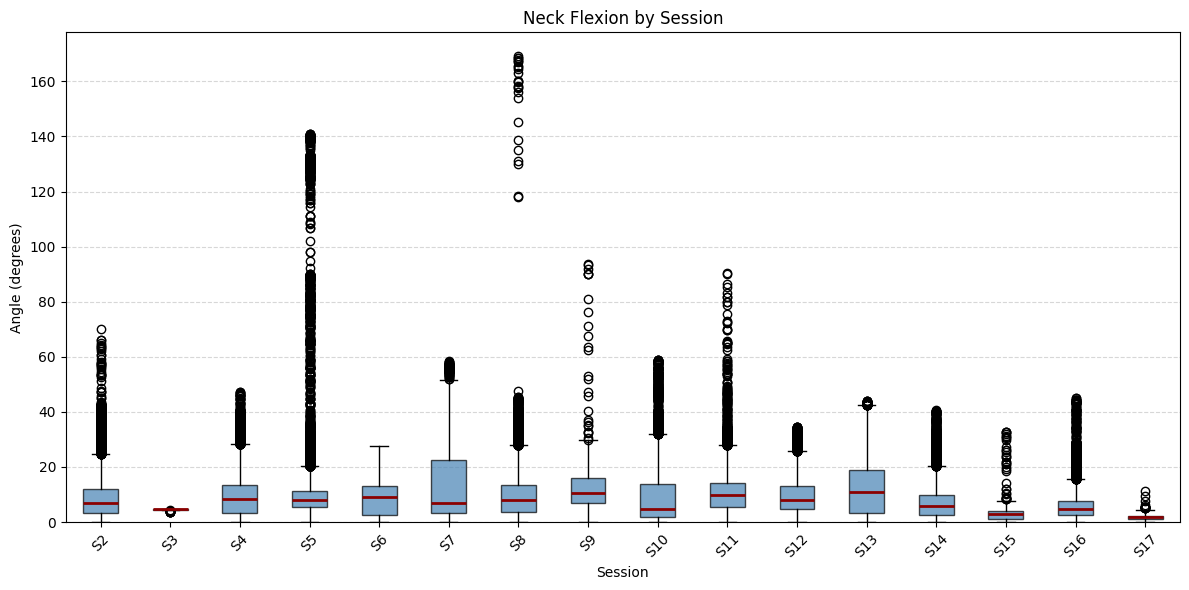

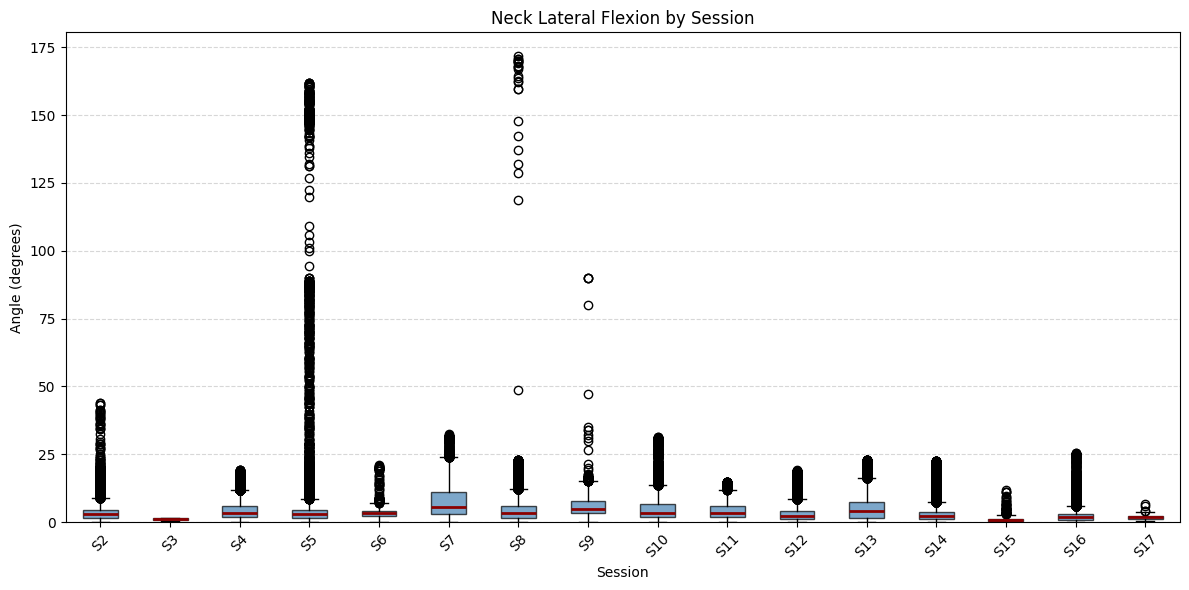

In [ ]:
# P04 Boxplot of Upper Body Angles by Session

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("p04_aggregate_kinematics.csv")

# Extract session numbers from filenames such as "P04 S2_kinematics.csv".
df["session"] = pd.to_numeric(
    df["file_name"].str.extract(r"(?i)\bs\s*(\d+)")[0],
    errors="coerce",
)

df = df.dropna(subset=["session"])
df["session"] = df["session"].astype(int)

upper_body_angles = [
    "left_shoulder_angle",
    "right_shoulder_angle",
    "left_elbow_angle",
    "right_elbow_angle",
    "trunk_flexion",
    "trunk_lateral_flexion",
    "neck_flexion",
    "neck_lateral_flexion",
]

# Keep only columns present in the CSV.
upper_body_angles = [
    angle for angle in upper_body_angles if angle in df.columns
]

session_order = sorted(df["session"].unique())

for angle in upper_body_angles:
    # Create one group of valid angle values for each session.
    session_data = [
        df.loc[df["session"] == session, angle].dropna().values
        for session in session_order
    ]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.boxplot(
        session_data,
        tick_labels=[f"S{session}" for session in session_order],
        patch_artist=True,
        boxprops={"facecolor": "steelblue", "alpha": 0.7},
        medianprops={"color": "darkred", "linewidth": 2},
    )

    ax.set_title(f"{angle.replace('_', ' ').title()} by Session")
    ax.set_xlabel("Session")
    ax.set_ylabel("Angle (degrees)")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

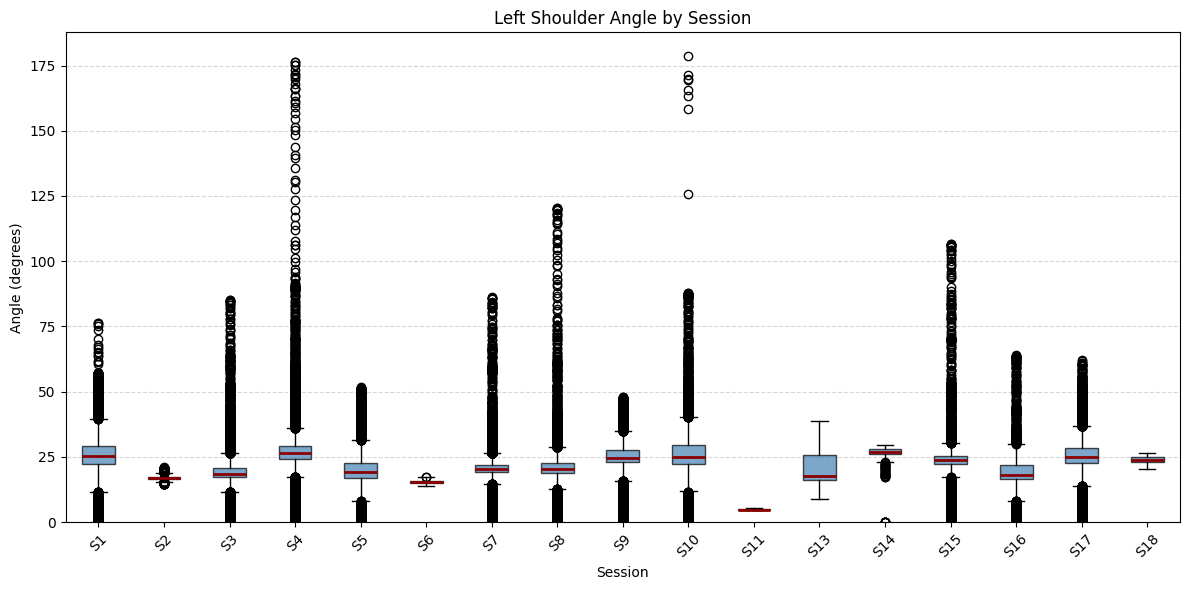

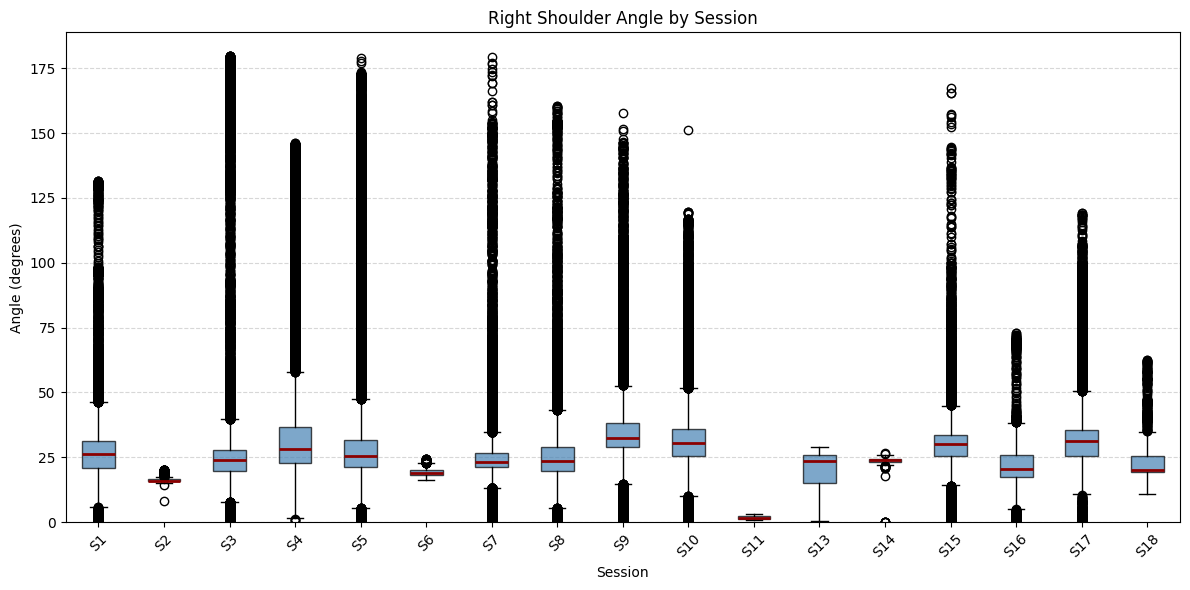

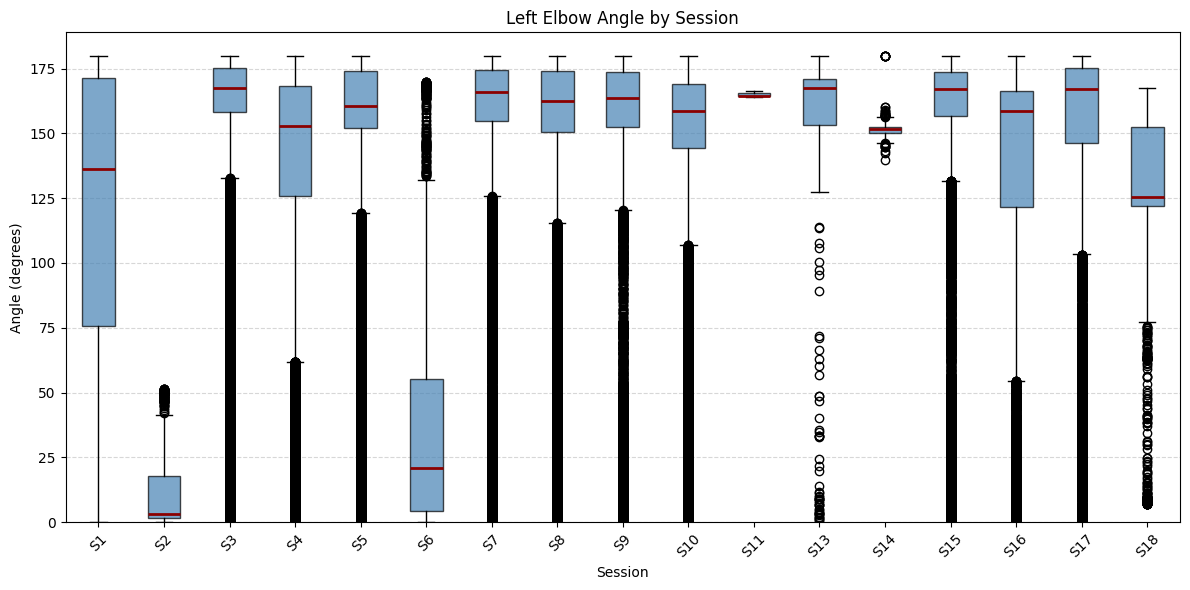

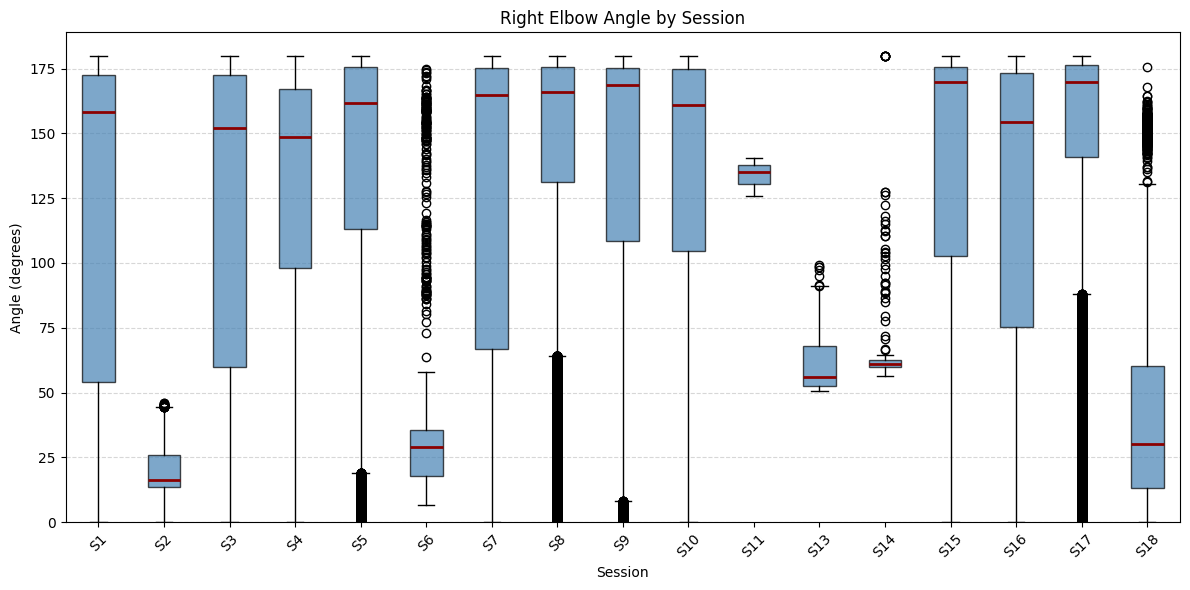

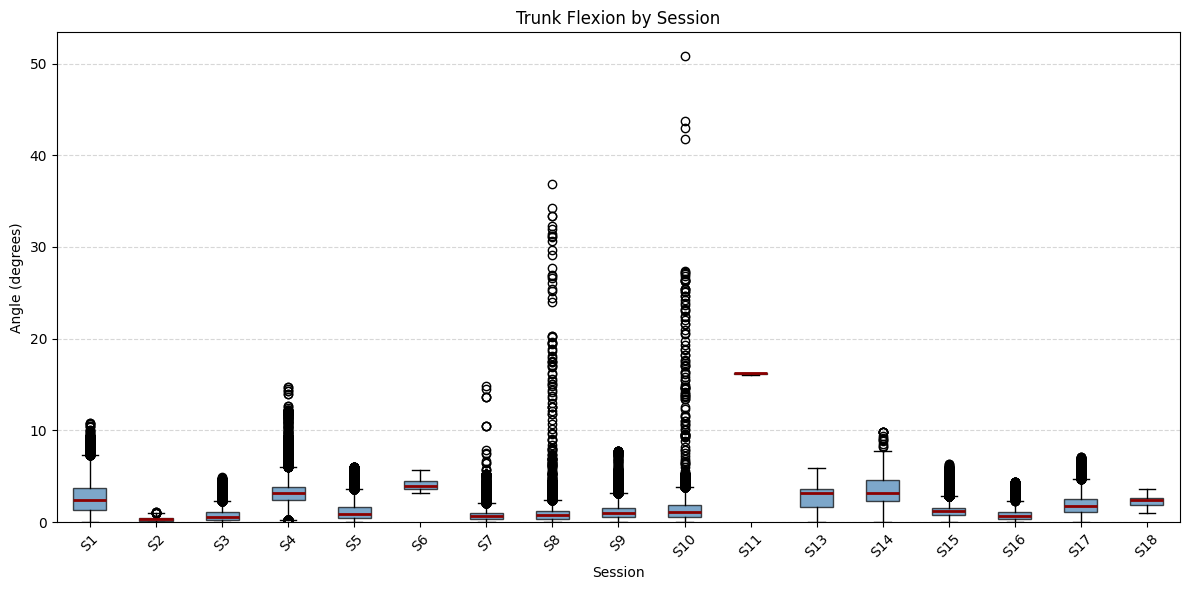

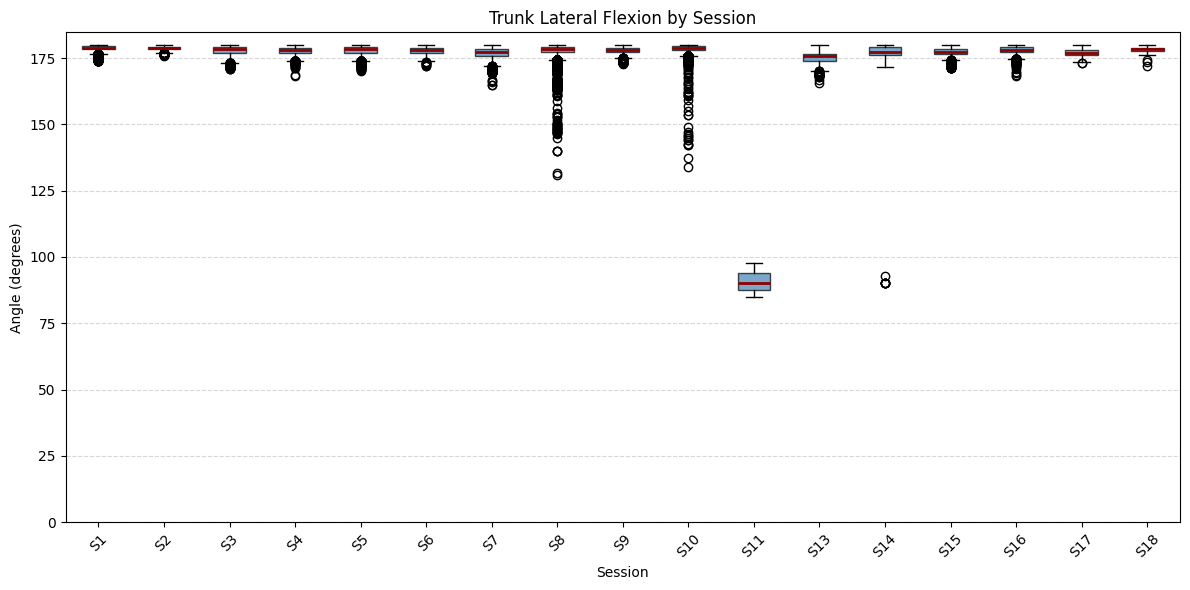

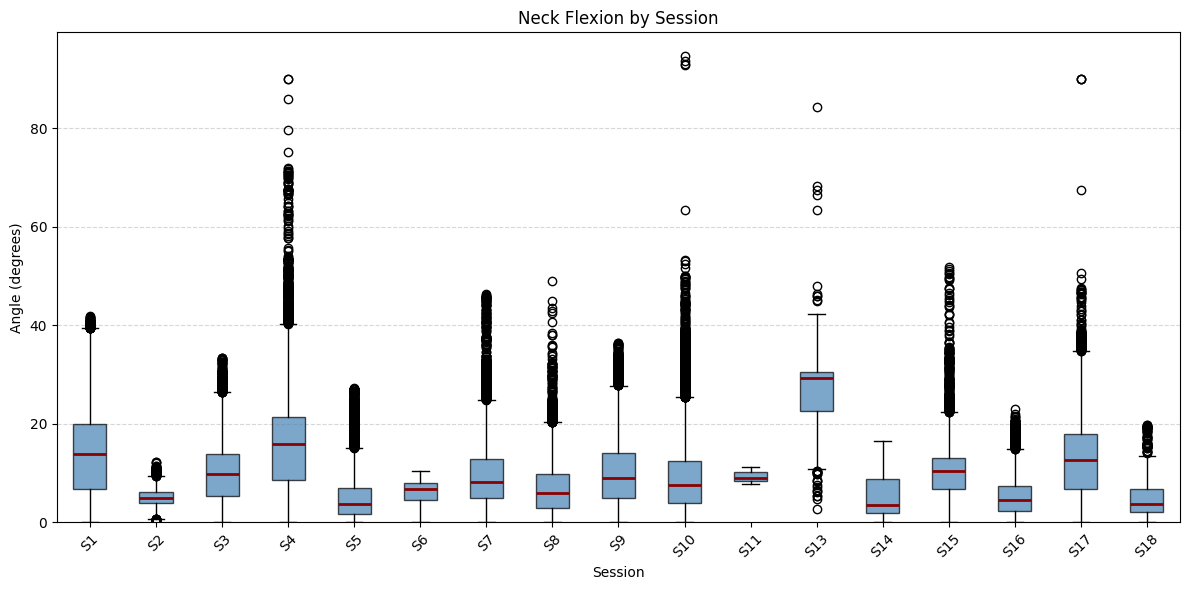

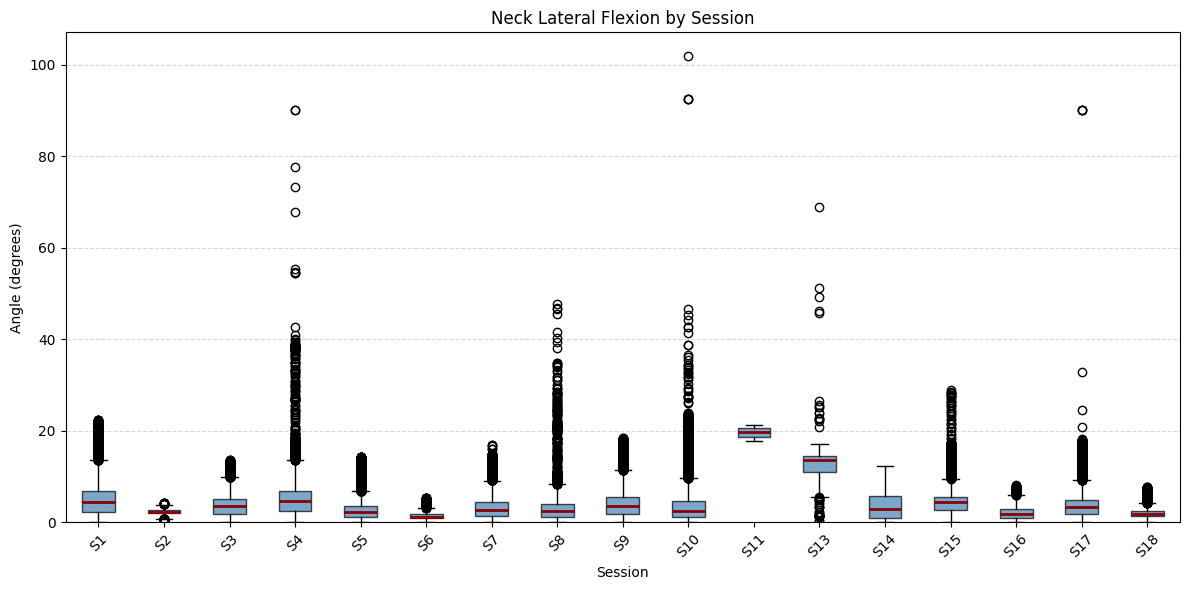

In [13]:
# P03 Boxplot of Upper Body Angles by Session

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("p03_aggregate_kinematics.csv")

# Extract session numbers from filenames such as "P04 S2_kinematics.csv".
df["session"] = pd.to_numeric(
    df["file_name"].str.extract(r"(?i)\bs\s*(\d+)")[0],
    errors="coerce",
)

df = df.dropna(subset=["session"])
df["session"] = df["session"].astype(int)

upper_body_angles = [
    "left_shoulder_angle",
    "right_shoulder_angle",
    "left_elbow_angle",
    "right_elbow_angle",
    "trunk_flexion",
    "trunk_lateral_flexion",
    "neck_flexion",
    "neck_lateral_flexion",
]

# Keep only columns present in the CSV.
upper_body_angles = [
    angle for angle in upper_body_angles if angle in df.columns
]

session_order = sorted(df["session"].unique())

for angle in upper_body_angles:
    # Create one group of valid angle values for each session.
    session_data = [
        df.loc[df["session"] == session, angle].dropna().values
        for session in session_order
    ]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.boxplot(
        session_data,
        tick_labels=[f"S{session}" for session in session_order],
        patch_artist=True,
        boxprops={"facecolor": "steelblue", "alpha": 0.7},
        medianprops={"color": "darkred", "linewidth": 2},
    )

    ax.set_title(f"{angle.replace('_', ' ').title()} by Session")
    ax.set_xlabel("Session")
    ax.set_ylabel("Angle (degrees)")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

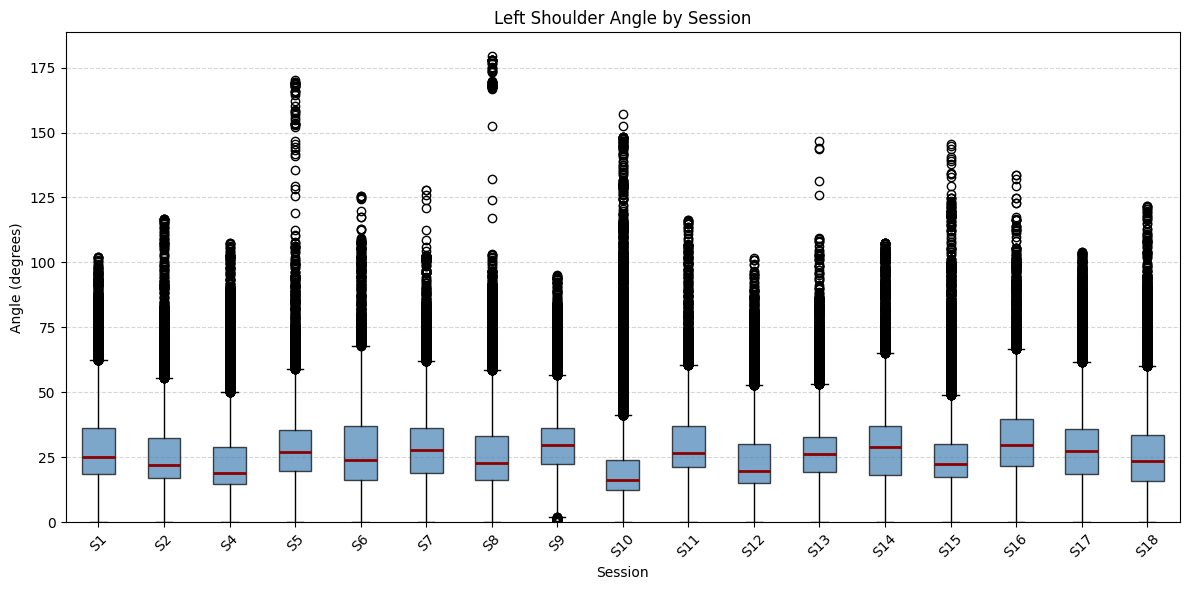

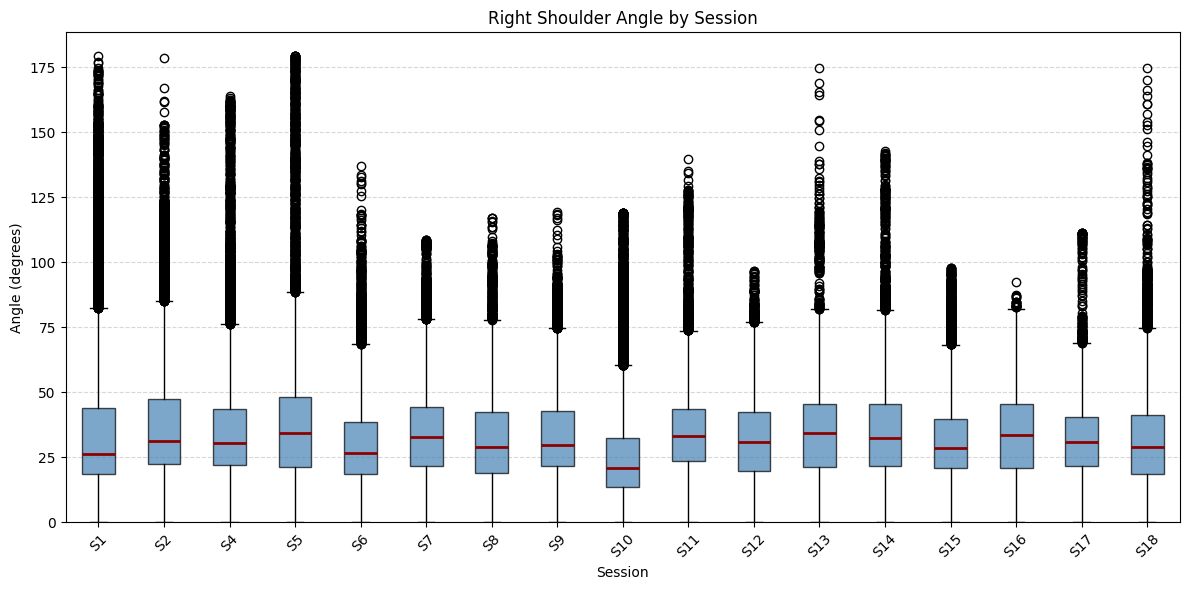

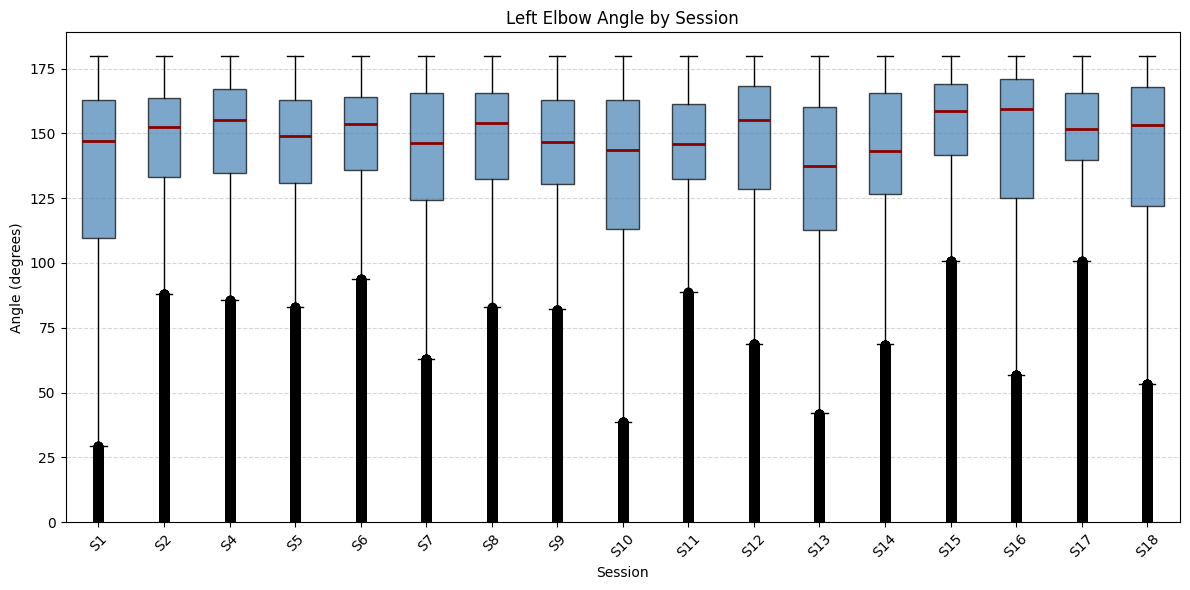

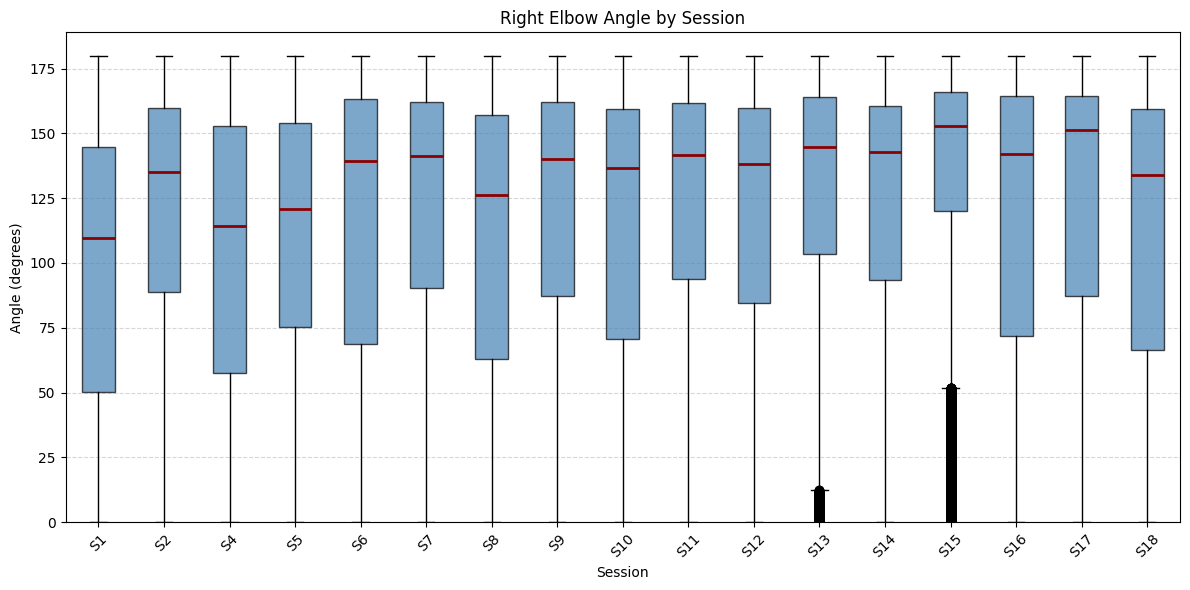

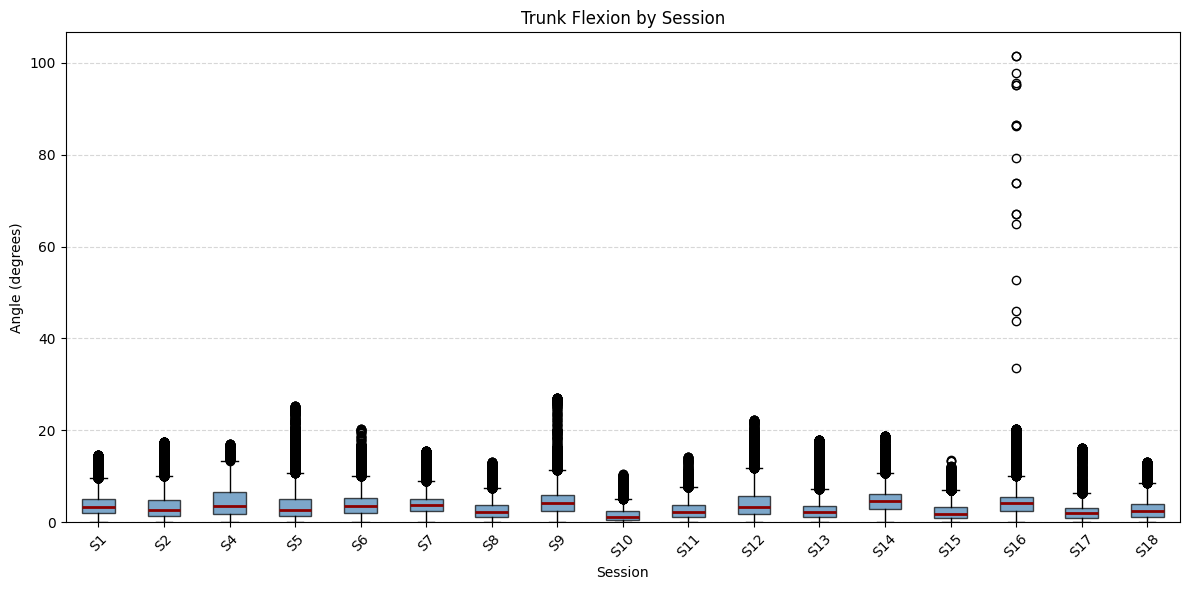

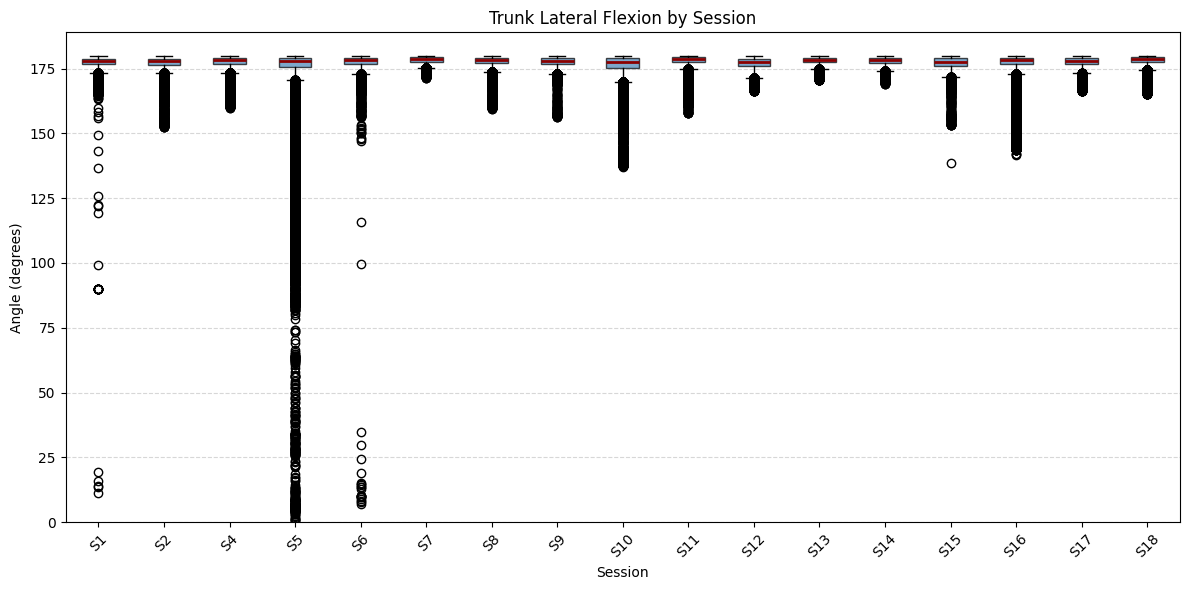

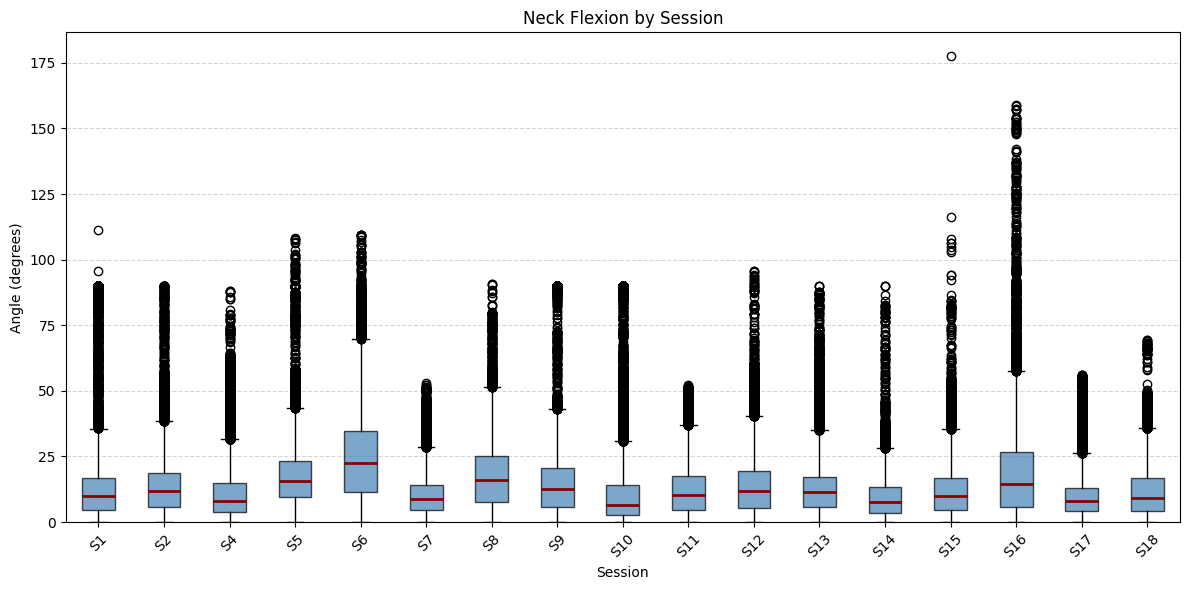

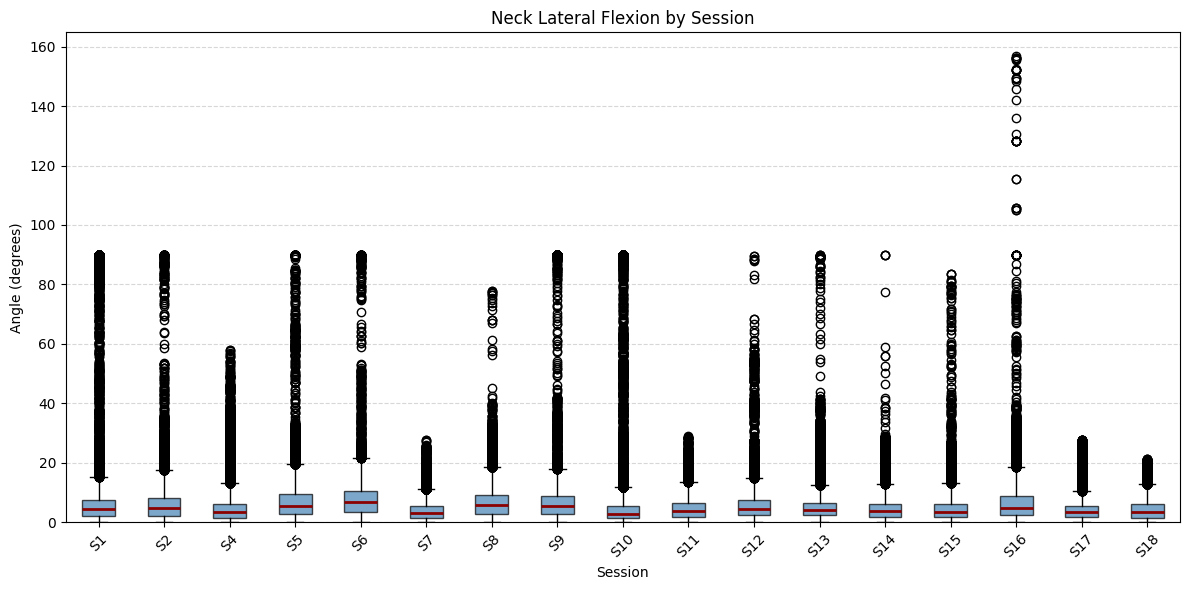

In [ ]:
# P01 Boxplot of Upper Body Angles by Session

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("p01_aggregate_kinematics.csv")

# Extract session numbers from filenames such as "P04 S2_kinematics.csv".
df["session"] = pd.to_numeric(
    df["file_name"].str.extract(r"(?i)\bs\s*(\d+)")[0],
    errors="coerce",
)

df = df.dropna(subset=["session"])
df["session"] = df["session"].astype(int)

upper_body_angles = [
    "left_shoulder_angle",
    "right_shoulder_angle",
    "left_elbow_angle",
    "right_elbow_angle",
    "trunk_flexion",
    "trunk_lateral_flexion",
    "neck_flexion",
    "neck_lateral_flexion",
]

# Keep only columns present in the CSV.
upper_body_angles = [
    angle for angle in upper_body_angles if angle in df.columns
]

session_order = sorted(df["session"].unique())

for angle in upper_body_angles:
    # Create one group of valid angle values for each session.
    session_data = [
        df.loc[df["session"] == session, angle].dropna().values
        for session in session_order
    ]

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.boxplot(
        session_data,
        tick_labels=[f"S{session}" for session in session_order],
        patch_artist=True,
        boxprops={"facecolor": "steelblue", "alpha": 0.7},
        medianprops={"color": "darkred", "linewidth": 2},
    )

    ax.set_title(f"{angle.replace('_', ' ').title()} by Session")
    ax.set_xlabel("Session")
    ax.set_ylabel("Angle (degrees)")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Please enter a whole frame number of 0 or greater.
Selected starting frames: {1: 6, 2: 6, 3: 6, 4: 6, 5: 6, 6: 6, 7: 6, 8: 6, 9: 6, 10: 6, 11: 6, 12: 6, 14: 6, 15: 6, 16: 6, 17: 6, 18: 6}
Total maxima per session: {'S1': 10195, 'S2': 8733, 'S3': 8303, 'S4': 9468, 'S5': 8335, 'S6': 8799, 'S7': 10223, 'S8': 8300, 'S9': 8534, 'S10': 28012, 'S11': 9291, 'S12': 8758, 'S14': 8941, 'S15': 8614, 'S16': 8924, 'S17': 8828, 'S18': 9379}


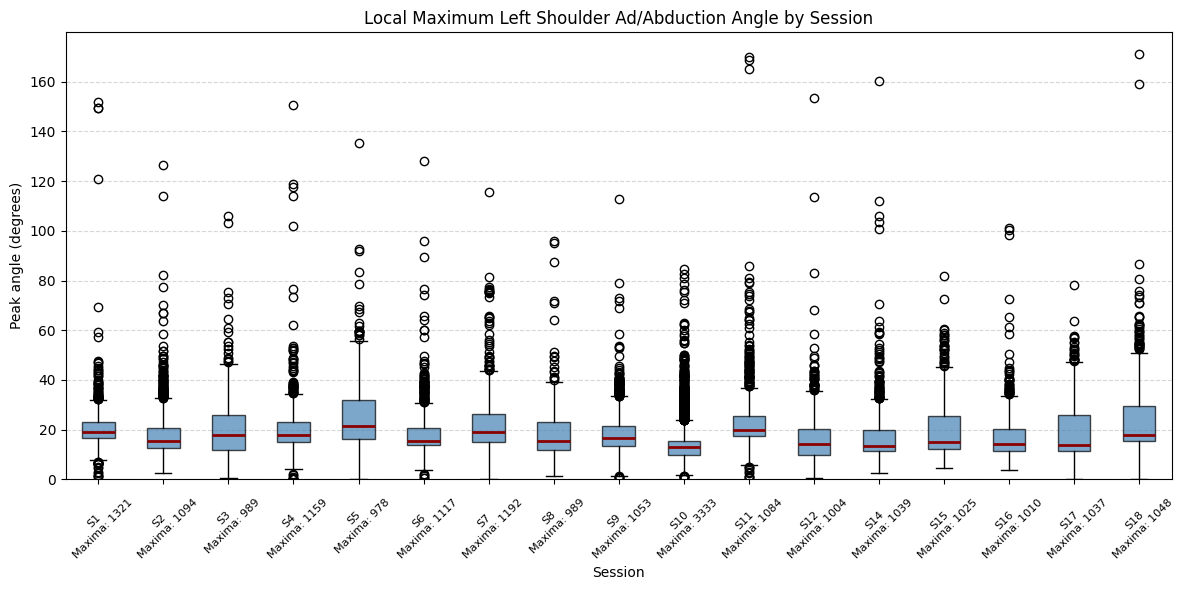

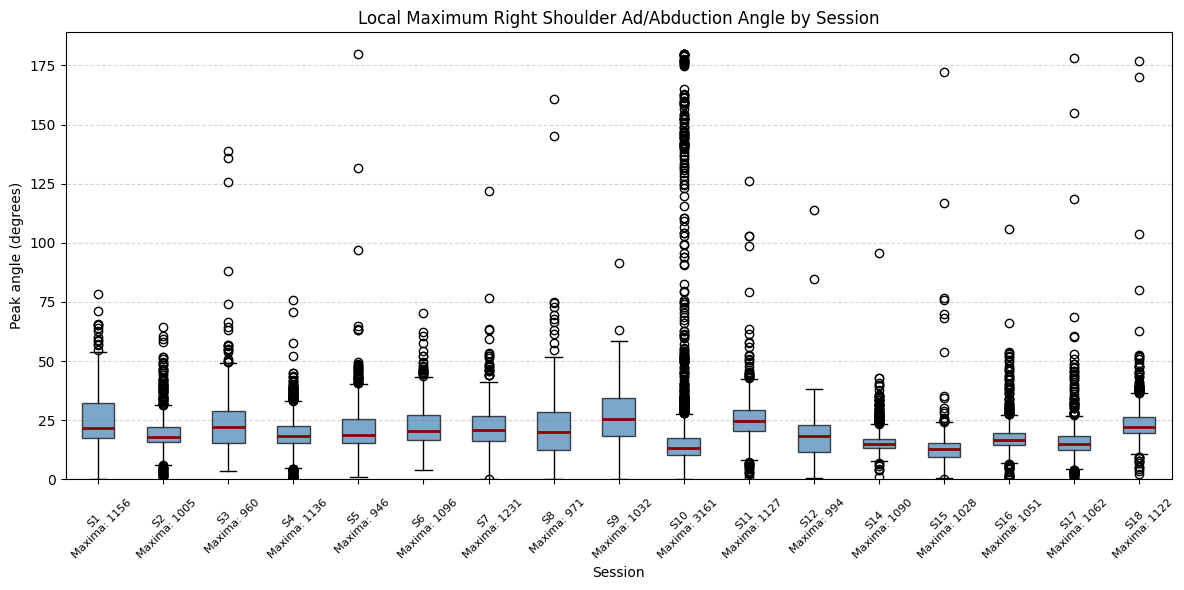

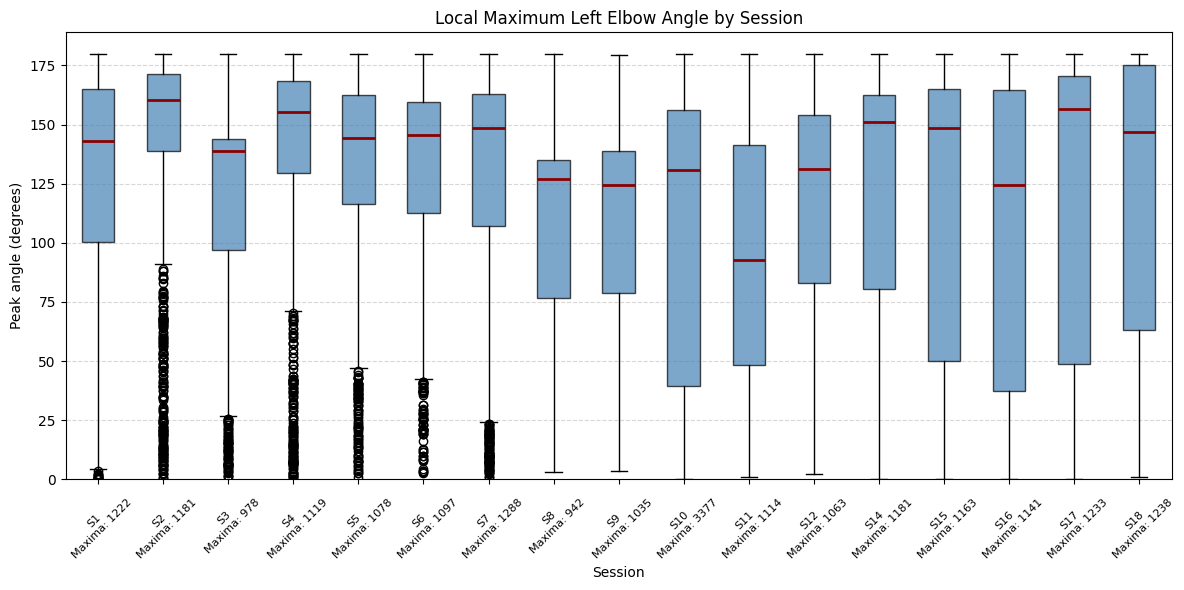

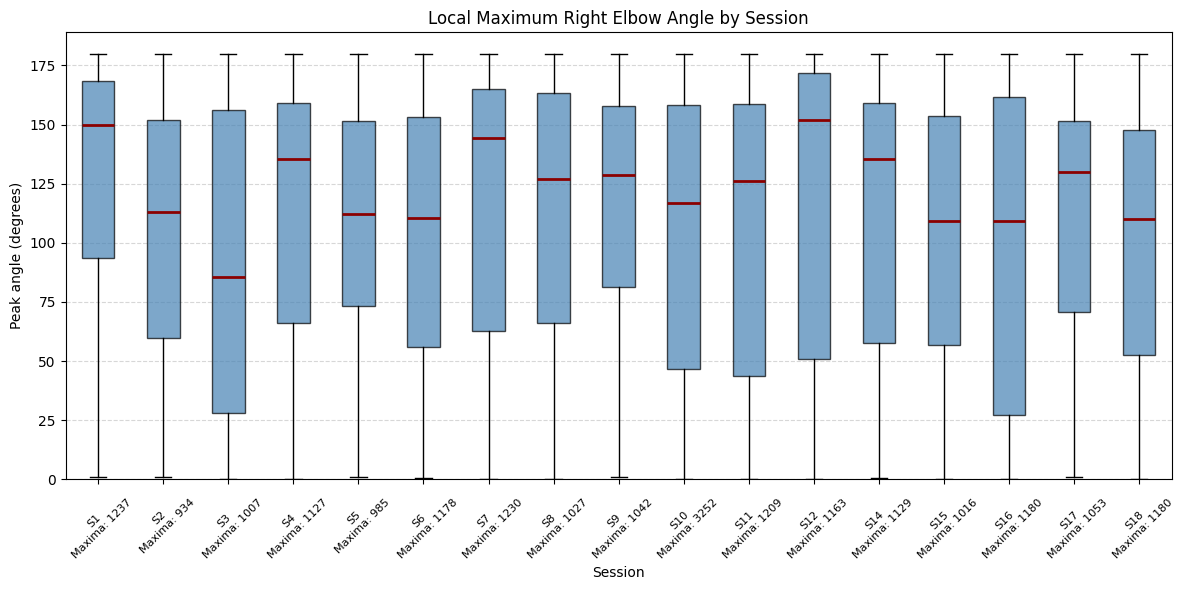

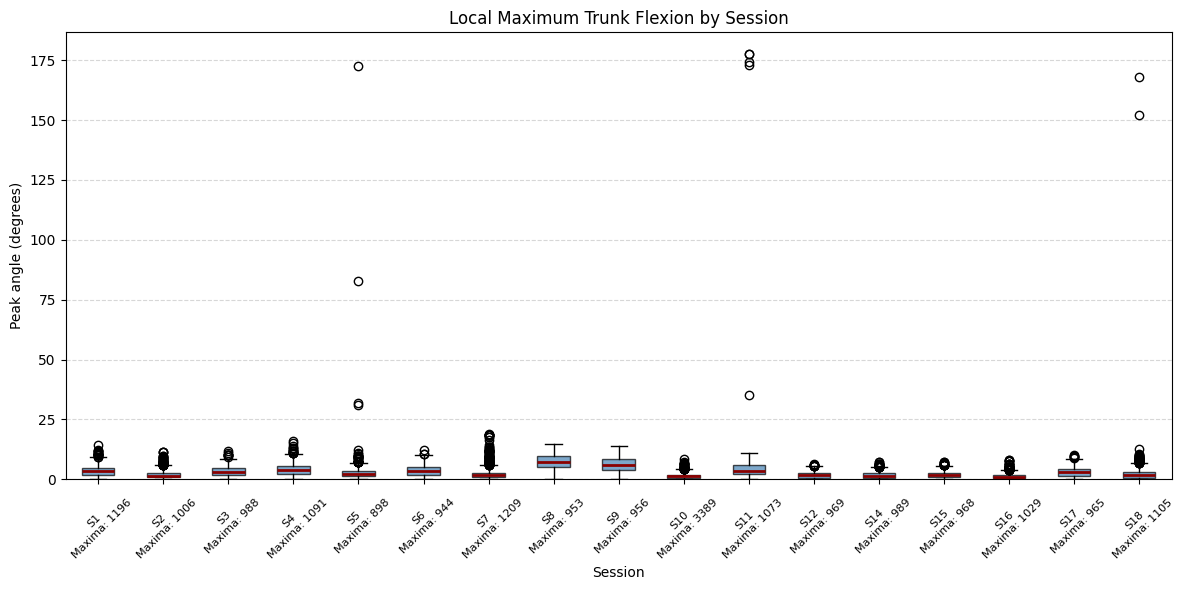

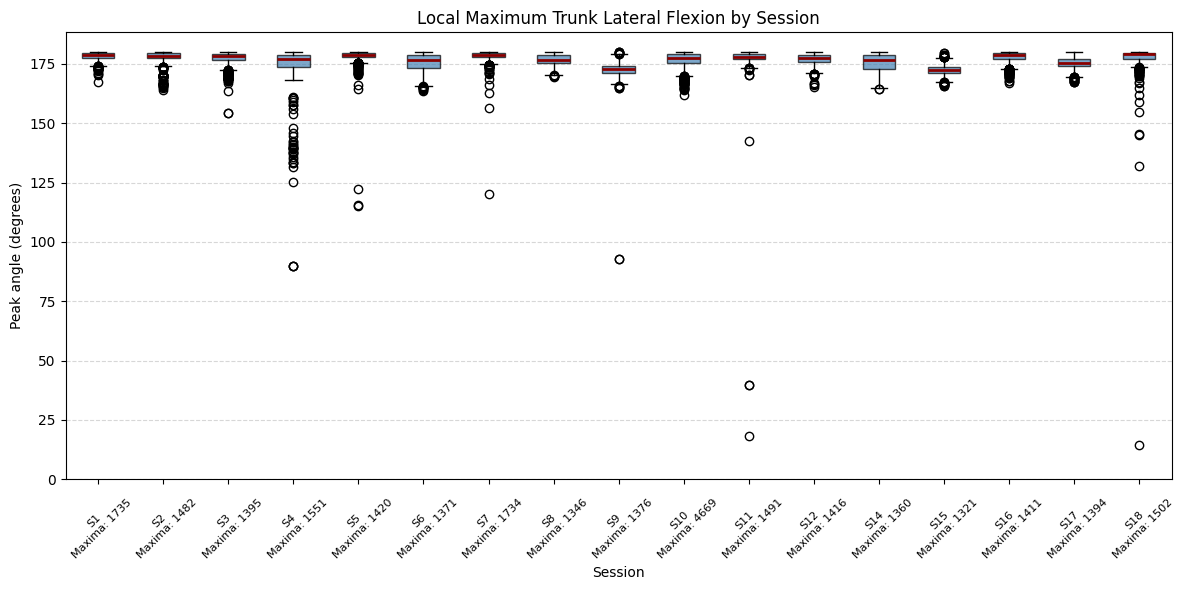

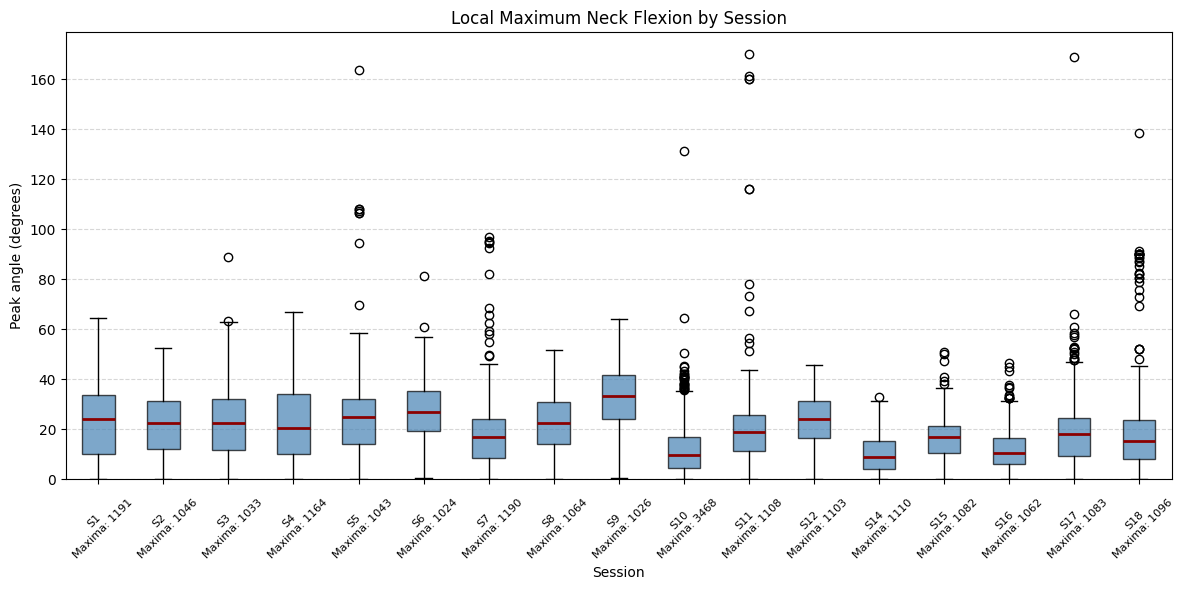

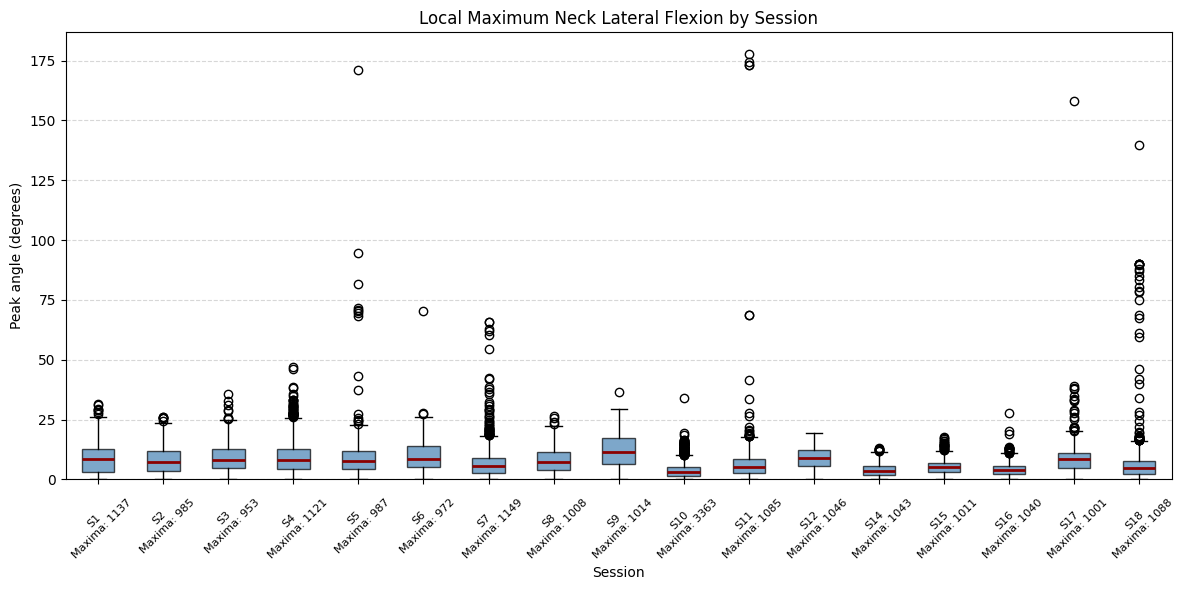

In [ ]:
# P02 Boxplot of Upper Body Angles by Session

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter


def detect_joint_cycle_maxima(
    angle_values,
    fps=30,
    minimum_rep_seconds=0.3,
    return_window_seconds=1.0,
):
    """Return maxima only for completed low-to-high-to-low joint cycles."""
    angle_values = np.asarray(angle_values, dtype=float)

    if angle_values.size < 11:
        return np.array([], dtype=int), np.array([], dtype=float)

    window_length = min(15, angle_values.size)
    if window_length % 2 == 0:
        window_length -= 1

    smoothed_angles = savgol_filter(
        angle_values, window_length=window_length, polyorder=2
    )
    candidate_indices, _ = find_peaks(
        smoothed_angles,
        distance=max(1, int(minimum_rep_seconds * fps)),
    )
    search_window = max(1, int(return_window_seconds * fps))
    valid_indices = []

    for peak_index in candidate_indices:
        before_start = max(0, peak_index - search_window)
        after_end = min(angle_values.size, peak_index + search_window + 1)
        before_peak = smoothed_angles[before_start:peak_index]
        after_peak = smoothed_angles[peak_index + 1:after_end]
        if before_peak.size == 0 or after_peak.size == 0:
            continue

        peak_value = smoothed_angles[peak_index]
        before_minimum = np.min(before_peak)
        after_minimum = np.min(after_peak)
        lowered_before = before_minimum < peak_value
        lowered_after = after_minimum < peak_value
        if lowered_before and lowered_after:
            valid_indices.append(peak_index)

    valid_indices = np.asarray(valid_indices, dtype=int)
    return valid_indices, angle_values[valid_indices]

input_folder = Path("p02_kinematics")
csv_files = sorted(input_folder.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {input_folder.resolve()}")

dataframes = []
start_frames = {}

for csv_file in csv_files:
    session_match = re.search(r"(?i)\bs\s*(\d+)", csv_file.stem)
    if session_match is None:
        print(f"Skipping {csv_file.name}: session number not found in filename.")
        continue

    session = int(session_match.group(1))

    while True:
        try:
            start_frame = int(input(f"Starting frame for {csv_file.name}: "))
            if start_frame < 0:
                raise ValueError
            break
        except ValueError:
            print("Please enter a whole frame number of 0 or greater.")

    session_df = pd.read_csv(csv_file)
    session_df = session_df.loc[session_df["frame"] >= start_frame].copy()

    if session_df.empty:
        print(f"Skipping {csv_file.name}: no rows exist from frame {start_frame} onward.")
        continue

    session_df["session"] = session
    session_df["start_frame"] = start_frame
    start_frames[session] = start_frame
    dataframes.append(session_df)

if not dataframes:
    raise ValueError("None of the P02 CSV files contained data at the selected starting frames.")

df = pd.concat(dataframes, ignore_index=True)
print("Selected starting frames:", dict(sorted(start_frames.items())))

joint_angles = [
    "left_shoulder_angle",
    "right_shoulder_angle",
    "left_elbow_angle",
    "right_elbow_angle",
    "trunk_flexion",
    "trunk_lateral_flexion",
    "neck_flexion",
    "neck_lateral_flexion",
]

# Keep only columns present in the CSV.
joint_angles = [
    angle for angle in joint_angles if angle in df.columns
]

session_order = sorted(df["session"].unique())

# Detect every local maximum before drawing so totals can be printed first.
peak_data_by_angle = {}
peak_counts_by_angle = {}
total_maxima_per_session = {session: 0 for session in session_order}

for angle in joint_angles:
    session_peak_data = []
    peak_counts = {}

    for session in session_order:
        angle_data = (
            df.loc[df["session"] == session, ["frame", angle]]
            .dropna()
            .sort_values("frame")
        )
        angle_values = angle_data[angle].to_numpy()

        peak_indices, peak_angles = detect_joint_cycle_maxima(
            angle_values,
            fps=30,
            minimum_rep_seconds=0.3,
            return_window_seconds=1.0,
        )

        peak_count = len(peak_angles)
        session_peak_data.append(peak_angles)
        peak_counts[session] = peak_count
        total_maxima_per_session[session] += peak_count

    peak_data_by_angle[angle] = session_peak_data
    peak_counts_by_angle[angle] = peak_counts

print(
    "Total maxima per session:",
    {f"S{session}": total_maxima_per_session[session] for session in session_order},
)

# Display each joint in its own separate graph.
for angle in joint_angles:
    session_peak_data = peak_data_by_angle[angle]
    peak_counts = peak_counts_by_angle[angle]
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(
        session_peak_data,
        tick_labels=[
            f"S{session}\nMaxima: {peak_counts[session]}"
            for session in session_order
        ],
        patch_artist=True,
        boxprops={"facecolor": "steelblue", "alpha": 0.7},
        medianprops={"color": "darkred", "linewidth": 2},
    )

    angle_title = {
        "left_shoulder_angle": "Left Shoulder Ad/Abduction Angle",
        "right_shoulder_angle": "Right Shoulder Ad/Abduction Angle",
    }.get(angle, angle.replace("_", " ").title())
    ax.set_title(f"P02 Fishing {angle_title} by Session")
    ax.set_xlabel("Session")
    ax.set_ylabel("Peak angle (degrees)")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)

    fig.tight_layout()
    plt.show()